In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = "C:/Users/amans/OneDrive/Desktop/kaggel data set/"

customers = pd.read_csv(path + 'olist_customers_dataset.csv')
orders = pd.read_csv(path + 'olist_orders_dataset.csv')
order_items = pd.read_csv(path + 'olist_order_items_dataset.csv')
payments = pd.read_csv(path + 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
products = pd.read_csv(path + 'olist_products_dataset.csv')
sellers = pd.read_csv(path + 'olist_sellers_dataset.csv')

print("Data loaded successfully! ✅")

Data loaded successfully! ✅


In [2]:
# Let's explore our datasets
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)


In [3]:
# Let's see first 5 rows of main datasets
print("=== ORDERS ===")
print(orders.head())

print("\n=== CUSTOMERS ===")
print(customers.head())

print("\n=== ORDER ITEMS ===")
print(order_items.head())

=== ORDERS ===
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00   

In [4]:
# Check column names
print("Orders columns:", orders.columns.tolist())
print("Customers columns:", customers.columns.tolist())
print("Order Items columns:", order_items.columns.tolist())
print("Payments columns:", payments.columns.tolist())

Orders columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
Customers columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
Order Items columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
Payments columns: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


In [5]:
# Check missing values in each dataset
print("=== MISSING VALUES ===")
print("\nOrders:\n", orders.isnull().sum())
print("\nCustomers:\n", customers.isnull().sum())
print("\nOrder Items:\n", order_items.isnull().sum())
print("\nPayments:\n", payments.isnull().sum())
print("\nReviews:\n", reviews.isnull().sum())
print("\nProducts:\n", products.isnull().sum())
print("\nSellers:\n", sellers.isnull().sum())

=== MISSING VALUES ===

Orders:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Customers:
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Order Items:
 order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Payments:
 order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Reviews:
 review_id                      0
order_id                       0
review_score                   0
review

In [6]:
# === DATA CLEANING - FINAL VERSION ===

# 1. Convert date columns to datetime format
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# 2. Fill missing dates
orders['order_approved_at'] = orders['order_approved_at'].ffill()
orders['order_delivered_carrier_date'] = orders['order_delivered_carrier_date'].ffill()
orders['order_delivered_customer_date'] = orders['order_delivered_customer_date'].ffill()

# 3. Fix Products
products['product_category_name'] = products['product_category_name'].fillna('Unknown')
products.dropna(inplace=True)

# 4. Check duplicates
print("Duplicate orders:", orders.duplicated().sum())
print("Duplicate customers:", customers.duplicated().sum())
print("Duplicate products:", products.duplicated().sum())

print("\nData Cleaning Done! ✅")

Duplicate orders: 0
Duplicate customers: 0
Duplicate products: 0

Data Cleaning Done! ✅


In [7]:
# === DATA ANALYSIS ===

# 1. Total Revenue
total_revenue = order_items['price'].sum()
print(f"Total Revenue: R$ {total_revenue:,.2f}")

# 2. Total Orders
total_orders = orders['order_id'].nunique()
print(f"Total Orders: {total_orders:,}")

# 3. Total Customers
total_customers = customers['customer_id'].nunique()
print(f"Total Customers: {total_customers:,}")

# 4. Total Products
total_products = products['product_id'].nunique()
print(f"Total Products: {total_products:,}")

# 5. Average Order Value
avg_order_value = order_items.groupby('order_id')['price'].sum().mean()
print(f"Average Order Value: R$ {avg_order_value:,.2f}")

# 6. Average Review Score
avg_review = reviews['review_score'].mean()
print(f"Average Review Score: {avg_review:.2f} / 5")

# 7. Order Status Distribution
print("\n=== ORDER STATUS ===")
print(orders['order_status'].value_counts())

Total Revenue: R$ 13,591,643.70
Total Orders: 99,441
Total Customers: 99,441
Total Products: 32,340
Average Order Value: R$ 137.75
Average Review Score: 4.09 / 5

=== ORDER STATUS ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [8]:
# === TIME ANALYSIS ===

# Extract month and year from order date
orders['order_month'] = orders['order_purchase_timestamp'].dt.month
orders['order_year'] = orders['order_purchase_timestamp'].dt.year
orders['order_monthyear'] = orders['order_purchase_timestamp'].dt.to_period('M')

# 1. Orders per year
print("=== ORDERS PER YEAR ===")
print(orders.groupby('order_year')['order_id'].count())

# 2. Orders per month
print("\n=== ORDERS PER MONTH ===")
print(orders.groupby('order_month')['order_id'].count())

=== ORDERS PER YEAR ===
order_year
2016      329
2017    45101
2018    54011
Name: order_id, dtype: int64

=== ORDERS PER MONTH ===
order_month
1      8069
2      8508
3      9893
4      9343
5     10573
6      9412
7     10318
8     10843
9      4305
10     4959
11     7544
12     5674
Name: order_id, dtype: int64


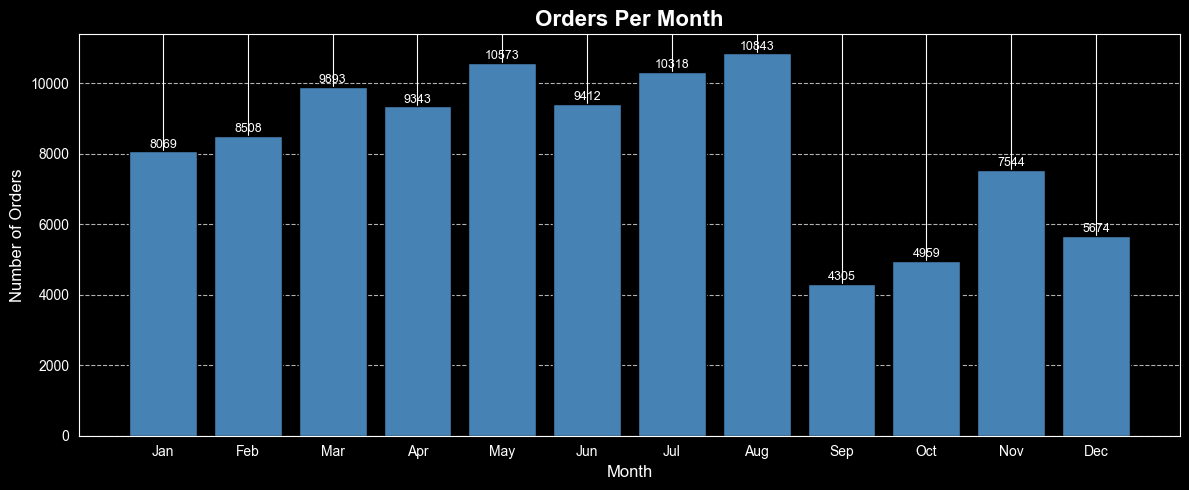

Chart saved! ✅


In [9]:
# === VISUALIZATIONS ===

# 1. Orders per Month - Bar Chart
plt.figure(figsize=(12, 5))
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_orders = orders.groupby('order_month')['order_id'].count()

plt.bar(month_names, monthly_orders.values, color='steelblue', edgecolor='black')
plt.title('Orders Per Month', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(monthly_orders.values):
    plt.text(i, v + 100, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('orders_per_month.png')
plt.show()
print("Chart saved! ✅")

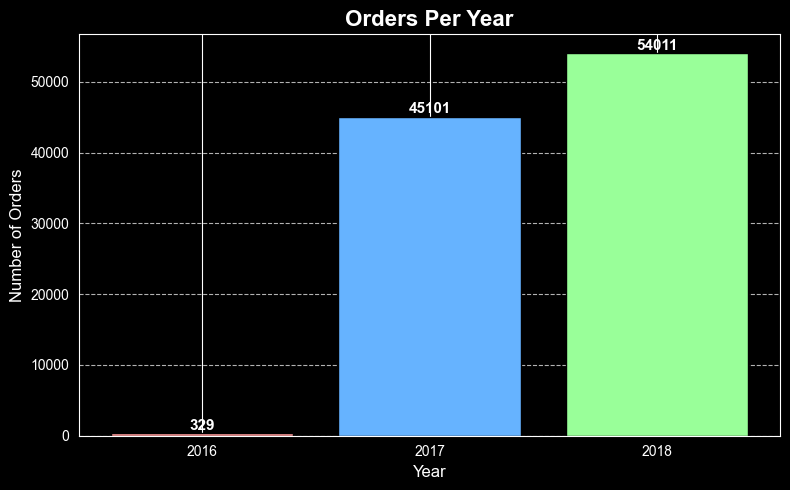

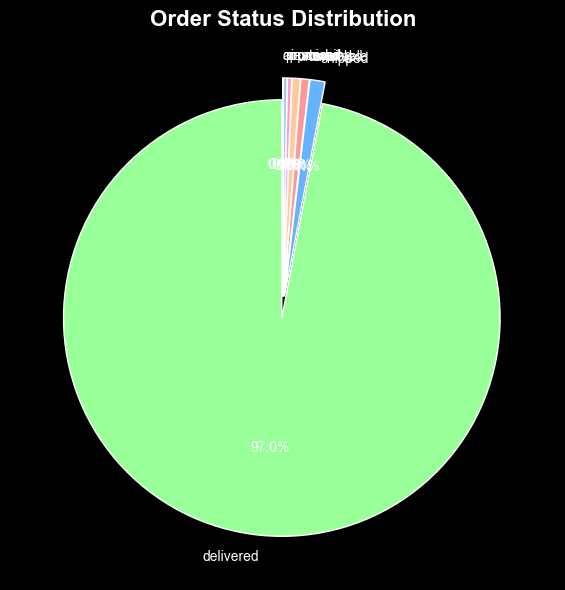

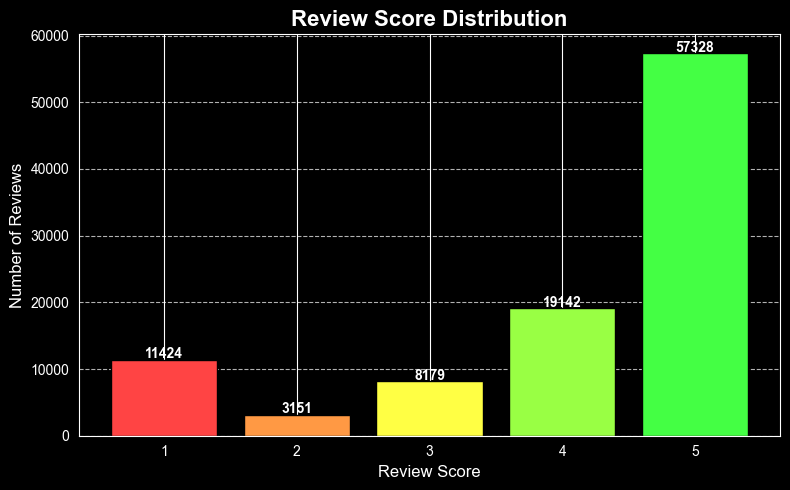

All charts saved! ✅


In [10]:
# 2. Orders Per Year - Bar Chart
plt.figure(figsize=(8, 5))
yearly_orders = orders.groupby('order_year')['order_id'].count()

plt.bar(['2016', '2017', '2018'], yearly_orders.values,
        color=['#ff9999', '#66b3ff', '#99ff99'], edgecolor='black')
plt.title('Orders Per Year', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(yearly_orders.values):
    plt.text(i, v + 500, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('orders_per_year.png')
plt.show()

# 3. Order Status - Pie Chart
plt.figure(figsize=(8, 6))
status_counts = orders['order_status'].value_counts()

plt.pie(status_counts.values,
        labels=status_counts.index,
        autopct='%1.1f%%',
        colors=['#99ff99','#66b3ff','#ff9999','#ffcc99','#ff99cc','#99ccff','#ffff99','#cc99ff'],
        startangle=90,
        explode=[0.05]*len(status_counts))

plt.title('Order Status Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('order_status.png')
plt.show()

# 4. Review Score Distribution - Bar Chart
plt.figure(figsize=(8, 5))
review_counts = reviews['review_score'].value_counts().sort_index()

colors = ['#ff4444', '#ff9944', '#ffff44', '#99ff44', '#44ff44']
plt.bar(review_counts.index, review_counts.values,
        color=colors, edgecolor='black')
plt.title('Review Score Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Review Score', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(review_counts.values):
    plt.text(i+1, v + 200, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('review_scores.png')
plt.show()

print("All charts saved! ✅")

In [11]:
# === REVENUE ANALYSIS ===

# 1. Merge orders with order_items to get revenue data
revenue_df = orders.merge(order_items, on='order_id', how='inner')

# 2. Revenue per Year
print("=== REVENUE PER YEAR ===")
yearly_revenue = revenue_df.groupby('order_year')['price'].sum()
print(yearly_revenue)

# 3. Revenue per Month
print("\n=== REVENUE PER MONTH ===")
monthly_revenue = revenue_df.groupby('order_month')['price'].sum()
print(monthly_revenue)

# 4. Top 10 most expensive products
print("\n=== TOP 10 HIGHEST VALUE ORDERS ===")
top_orders = order_items.groupby('order_id')['price'].sum().sort_values(ascending=False).head(10)
print(top_orders)

=== REVENUE PER YEAR ===
order_year
2016      49785.92
2017    6155806.98
2018    7386050.80
Name: price, dtype: float64

=== REVENUE PER MONTH ===
order_month
1     1070343.23
2     1091481.73
3     1357557.74
4     1356574.98
5     1502588.82
6     1298162.91
7     1393538.70
8     1428658.01
9      624814.05
10     713727.09
11    1010271.37
12     743925.07
Name: price, dtype: float64

=== TOP 10 HIGHEST VALUE ORDERS ===
order_id
03caa2c082116e1d31e67e9ae3700499    13440.0
736e1922ae60d0d6a89247b851902527     7160.0
0812eb902a67711a1cb742b3cdaa65ae     6735.0
fefacc66af859508bf1a7934eab1e97f     6729.0
f5136e38d1a14a4dbd87dff67da82701     6499.0
2cc9089445046817a7539d90805e6e5a     5934.6
a96610ab360d42a2e5335a3998b4718a     4799.0
199af31afc78c699f0dbf71fb178d4d4     4690.0
b4c4b76c642808cbe472a32b86cddc95     4599.9
8dbc85d1447242f3b127dda390d56e19     4590.0
Name: price, dtype: float64


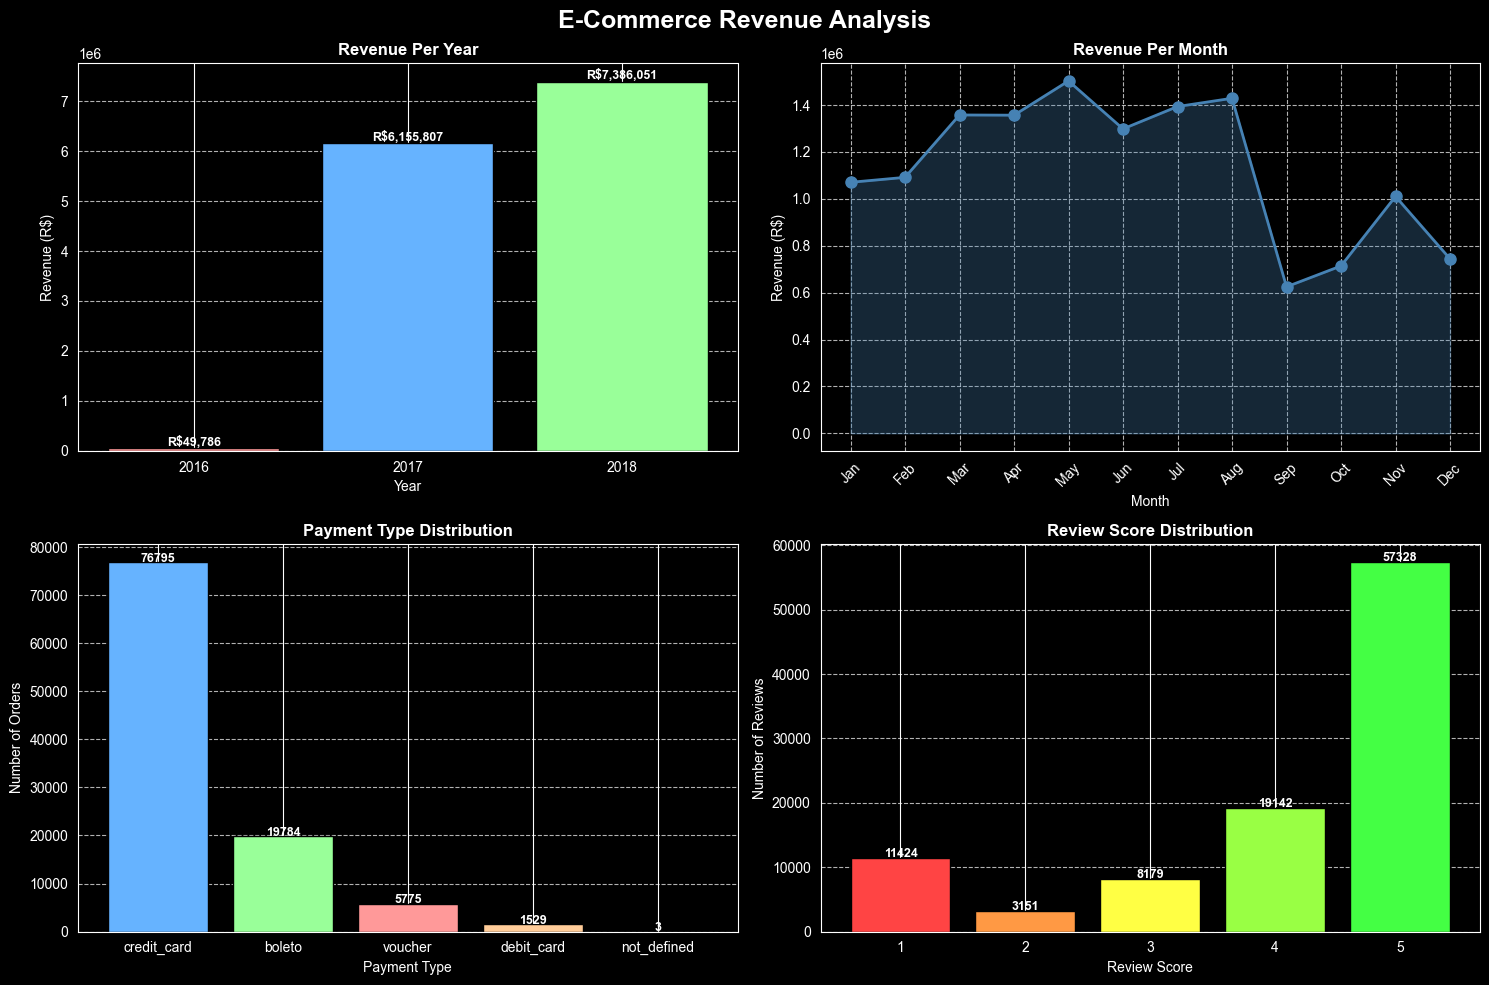

Revenue Analysis Chart saved! ✅


In [12]:
# === REVENUE VISUALIZATIONS ===

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('E-Commerce Revenue Analysis', fontsize=18, fontweight='bold')

# 1. Revenue Per Year
axes[0,0].bar(['2016', '2017', '2018'],
              yearly_revenue.values,
              color=['#ff9999', '#66b3ff', '#99ff99'],
              edgecolor='black')
axes[0,0].set_title('Revenue Per Year', fontweight='bold')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Revenue (R$)')
axes[0,0].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(yearly_revenue.values):
    axes[0,0].text(i, v + 50000, f'R${v:,.0f}', ha='center', fontsize=9, fontweight='bold')

# 2. Revenue Per Month - Line Chart
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0,1].plot(month_names, monthly_revenue.values,
               color='steelblue', marker='o', linewidth=2, markersize=8)
axes[0,1].fill_between(month_names, monthly_revenue.values, alpha=0.3, color='steelblue')
axes[0,1].set_title('Revenue Per Month', fontweight='bold')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Revenue (R$)')
axes[0,1].grid(linestyle='--', alpha=0.7)
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Payment Type Distribution
payment_type = payments['payment_type'].value_counts()
axes[1,0].bar(payment_type.index, payment_type.values,
              color=['#66b3ff', '#99ff99', '#ff9999', '#ffcc99'],
              edgecolor='black')
axes[1,0].set_title('Payment Type Distribution', fontweight='bold')
axes[1,0].set_xlabel('Payment Type')
axes[1,0].set_ylabel('Number of Orders')
axes[1,0].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(payment_type.values):
    axes[1,0].text(i, v + 100, str(v), ha='center', fontsize=9, fontweight='bold')

# 4. Review Score Distribution
review_counts = reviews['review_score'].value_counts().sort_index()
colors = ['#ff4444', '#ff9944', '#ffff44', '#99ff44', '#44ff44']
axes[1,1].bar(review_counts.index, review_counts.values,
              color=colors, edgecolor='black')
axes[1,1].set_title('Review Score Distribution', fontweight='bold')
axes[1,1].set_xlabel('Review Score')
axes[1,1].set_ylabel('Number of Reviews')
axes[1,1].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(review_counts.values):
    axes[1,1].text(i+1, v + 200, str(v), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('revenue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Revenue Analysis Chart saved! ✅")

In [13]:
# === TOP CATEGORIES & SELLERS ANALYSIS ===

# 1. Merge products with category translation
category_translation = pd.read_csv("C:/Users/amans/OneDrive/Desktop/kaggel data set/product_category_name_translation.csv")
products_translated = products.merge(category_translation, on='product_category_name', how='left')

# 2. Merge order_items with products
items_products = order_items.merge(products_translated, on='product_id', how='left')

# 3. Top 10 categories by revenue
print("=== TOP 10 CATEGORIES BY REVENUE ===")
top_categories = items_products.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)
print(top_categories)

# 4. Top 10 sellers by revenue
print("\n=== TOP 10 SELLERS BY REVENUE ===")
top_sellers = order_items.groupby('seller_id')['price'].sum().sort_values(ascending=False).head(10)
print(top_sellers)

=== TOP 10 CATEGORIES BY REVENUE ===
product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64

=== TOP 10 SELLERS BY REVENUE ===
seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    160236.57
7a67c85e85bb2ce8582c35f2203ad736    141745.53
1025f0e2d44d7041d6cf58b6550e0bfa    138968.55
955fee9216a65b617aa5c0531780ce60    135171.70
Name: price, dtype: float64


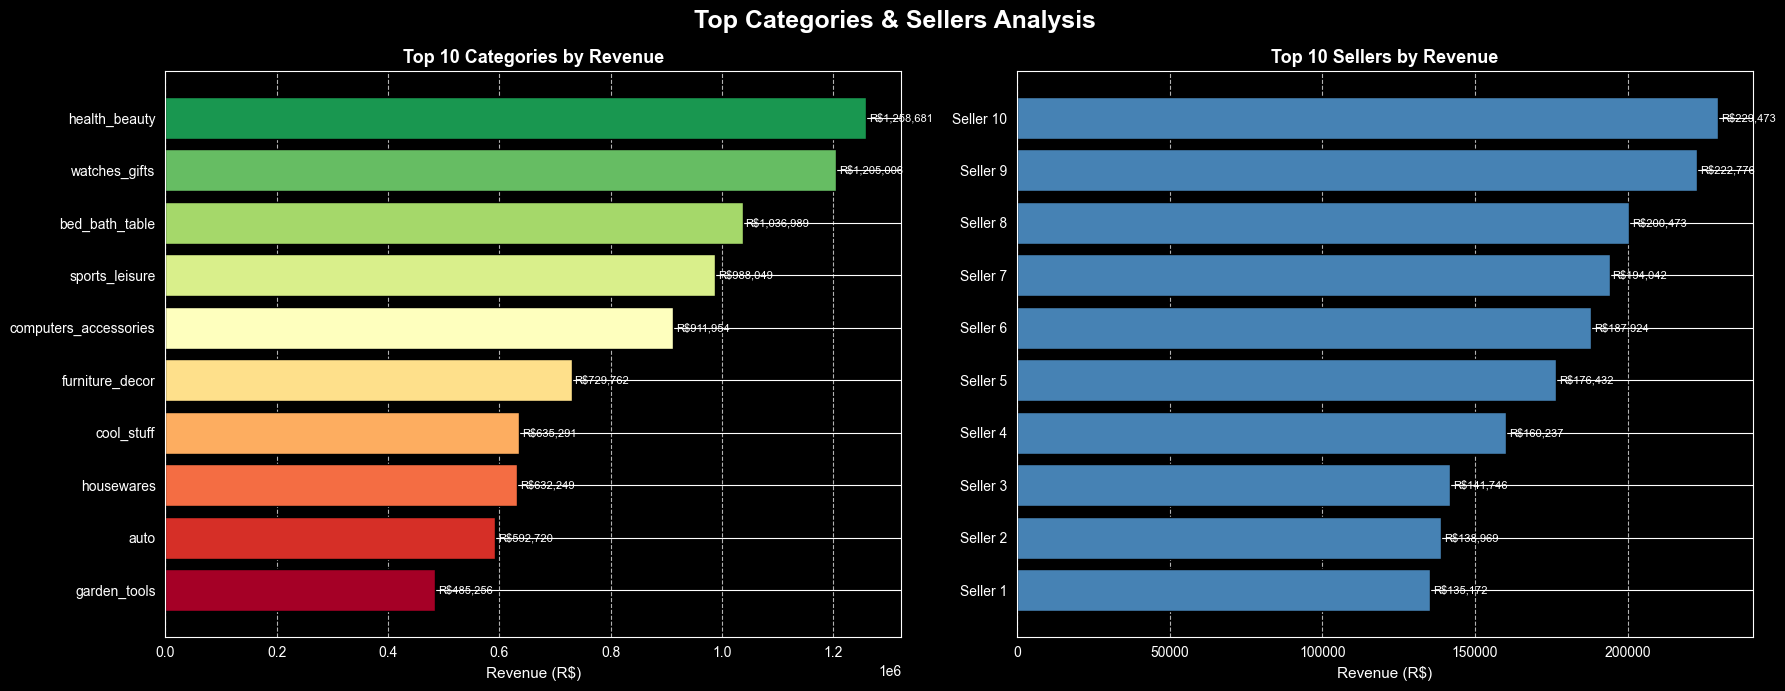

Categories & Sellers Chart saved! ✅


In [14]:
# === TOP CATEGORIES & SELLERS VISUALIZATION ===

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Top Categories & Sellers Analysis', fontsize=18, fontweight='bold')

# 1. Top 10 Categories - Horizontal Bar Chart
top_categories_sorted = top_categories.sort_values(ascending=True)
colors_cat = plt.cm.RdYlGn([i/10 for i in range(10)])

axes[0].barh(top_categories_sorted.index,
             top_categories_sorted.values,
             color=colors_cat,
             edgecolor='black')
axes[0].set_title('Top 10 Categories by Revenue', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Revenue (R$)', fontsize=11)
axes[0].grid(axis='x', linestyle='--', alpha=0.7)
for i, v in enumerate(top_categories_sorted.values):
    axes[0].text(v + 5000, i, f'R${v:,.0f}', va='center', fontsize=8)

# 2. Top 10 Sellers - Horizontal Bar Chart
top_sellers_sorted = top_sellers.sort_values(ascending=True)
seller_labels = [f'Seller {i+1}' for i in range(len(top_sellers_sorted))]

axes[1].barh(seller_labels,
             top_sellers_sorted.values,
             color='steelblue',
             edgecolor='black')
axes[1].set_title('Top 10 Sellers by Revenue', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Revenue (R$)', fontsize=11)
axes[1].grid(axis='x', linestyle='--', alpha=0.7)
for i, v in enumerate(top_sellers_sorted.values):
    axes[1].text(v + 1000, i, f'R${v:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('categories_sellers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Categories & Sellers Chart saved! ✅")

In [15]:
from sqlalchemy import create_engine
import urllib

# Connection string with your server name
params = urllib.parse.quote_plus(
    "DRIVER={SQL Server};"
    "SERVER=AMAN\\SQLEXPRESS;"
    "DATABASE=EcommerceDB;"
    "Trusted_Connection=yes;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# Test connection first
try:
    with engine.connect() as conn:
        print("Connection Successful! ✅")
except Exception as e:
    print("Connection Failed! ❌")
    print(e)

Connection Successful! ✅


In [16]:
from sqlalchemy import create_engine
import urllib

# Updated connection string with newer driver
params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=AMAN\\SQLEXPRESS;"
    "DATABASE=EcommerceDB;"
    "Trusted_Connection=yes;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# Test connection first
try:
    with engine.connect() as conn:
        print("Connection Successful! ✅")
except Exception as e:
    print("Connection Failed! ❌")
    print(e)

Connection Successful! ✅


In [17]:
# Fix Period column - convert to string
orders['order_monthyear'] = orders['order_monthyear'].astype(str)

# Now import all tables
try:
    print("Importing customers...")
    customers.to_sql('customers', engine, if_exists='replace', index=False)
    print("✅ Customers imported!")

    print("Importing orders...")
    orders.to_sql('orders', engine, if_exists='replace', index=False)
    print("✅ Orders imported!")

    print("Importing order items...")
    order_items.to_sql('order_items', engine, if_exists='replace', index=False)
    print("✅ Order items imported!")

    print("Importing payments...")
    payments.to_sql('payments', engine, if_exists='replace', index=False)
    print("✅ Payments imported!")

    print("Importing reviews...")
    reviews.to_sql('reviews', engine, if_exists='replace', index=False)
    print("✅ Reviews imported!")

    print("Importing products...")
    products.to_sql('products', engine, if_exists='replace', index=False)
    print("✅ Products imported!")

    print("Importing sellers...")
    sellers.to_sql('sellers', engine, if_exists='replace', index=False)
    print("✅ Sellers imported!")

    print("\n🎉 All tables imported successfully!")

except Exception as e:
    print(f"❌ Error: {e}")

Importing customers...
✅ Customers imported!
Importing orders...
✅ Orders imported!
Importing order items...
✅ Order items imported!
Importing payments...
✅ Payments imported!
Importing reviews...
✅ Reviews imported!
Importing products...
✅ Products imported!
Importing sellers...
✅ Sellers imported!

🎉 All tables imported successfully!


In [18]:
# Export data to Excel
print("Exporting data to Excel...")

# Create a summary dataframe
monthly_summary = revenue_df.groupby(['order_year', 'order_month']).agg(
    Total_Orders=('order_id', 'nunique'),
    Total_Revenue=('price', 'sum')
).reset_index()

monthly_summary['Total_Revenue'] = monthly_summary['Total_Revenue'].round(2)

# Export to Excel
with pd.ExcelWriter('C:/Users/amans/OneDrive/Desktop/Ecommerce_Analysis.xlsx', engine='openpyxl') as writer:
    monthly_summary.to_excel(writer, sheet_name='Monthly Summary', index=False)
    orders['order_status'].value_counts().reset_index().to_excel(writer, sheet_name='Order Status', index=False)
    top_categories.reset_index().to_excel(writer, sheet_name='Top Categories', index=False)
    payments['payment_type'].value_counts().reset_index().to_excel(writer, sheet_name='Payments', index=False)
    reviews['review_score'].value_counts().reset_index().to_excel(writer, sheet_name='Reviews', index=False)

print("Excel file exported successfully! ✅")
print("Check your Desktop for Ecommerce_Analysis.xlsx")

Exporting data to Excel...
Excel file exported successfully! ✅
Check your Desktop for Ecommerce_Analysis.xlsx
